# Datathon – Passos Mágicos

## Modelo Preditivo de Risco de Defasagem

Objetivo:
Desenvolver análises e um modelo preditivo capaz de identificar alunos com risco de defasagem educacional com base nos indicadores da ONG Passos Mágicos.

In [4]:
# ==============================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==============================

import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Salvar modelo
import joblib

In [5]:
# ==============================
# 2. CARREGAMENTO DA BASE
# ==============================

arquivo = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

xls = pd.ExcelFile(arquivo)

xls.sheet_names

['PEDE2022', 'PEDE2023', 'PEDE2024']

In [6]:
# ==============================
# 3. LEITURA DAS ABAS
# ==============================

pede_2022 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2022'
)

pede_2023 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2023'
)

pede_2024 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2024'
)

In [7]:
# ==============================
# 4. ENTENDIMENTO INICIAL
# ==============================

pede_2024.head()

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [8]:
pede_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [9]:
pede_2024.describe()

,Data de Nasc,Idade,Ano ingresso,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV
count,1156,1156.000000,1156.000000,472.000000,690.000000,0.0,0.0,0.0,1156.000000,0.0,...,1050.000000,474.000000,0.0,0.0,1054.000000,1156.000000,1156.000000,0.0,0.0,0.0
mean,2011-05-10 06:46:14.740484352,12.987889,2022.519896,7.368276,7.455472,NaN,NaN,NaN,2.951557,NaN,...,6.175762,6.595886,NaN,NaN,7.354268,7.683824,-0.409170,NaN,NaN,NaN
min,1996-12-08 02:00:00,7.000000,2021.000000,3.031806,4.406458,NaN,NaN,NaN,0.000000,NaN,...,0.000000,0.000000,NaN,NaN,2.943333,2.500000,-3.000000,NaN,NaN,NaN
25%,2009-02-28 18:00:00,10.000000,2021.000000,6.890881,6.862402,NaN,NaN,NaN,2.000000,NaN,...,5.000000,5.000000,NaN,NaN,6.790625,5.000000,-1.000000,NaN,NaN,NaN
50%,2012-01-07 00:00:00,12.000000,2023.000000,7.475431,7.559046,NaN,NaN,NaN,3.000000,NaN,...,6.500000,7.000000,NaN,NaN,7.500000,10.000000,0.000000,NaN,NaN,NaN
75%,2014-02-06 06:00:00,15.000000,2024.000000,7.981160,8.048758,NaN,NaN,NaN,4.000000,NaN,...,8.000000,9.000000,NaN,NaN,8.085000,10.000000,0.000000,NaN,NaN,NaN
max,2017-06-02 00:00:00,27.000000,2024.000000,9.441522,9.371200,NaN,NaN,NaN,6.000000,NaN,...,10.000000,10.000000,NaN,NaN,9.760000,10.000000,3.000000,NaN,NaN,NaN
std,NaN,3.584699,1.204804,0.861821,0.850390,NaN,NaN,NaN,1.397985,NaN,...,2.379552,2.876249,NaN,NaN,1.048541,2.504055,0.850497,NaN,NaN,NaN


In [13]:
# ==============================
# 5. LISTAGEM DAS COLUNAS
# ==============================

pede_2024.columns.tolist()

['RA',
 'Fase',
 'INDE 2024',
 'Pedra 2024',
 'Turma',
 'Nome Anonimizado',
 'Data de Nasc',
 'Idade',
 'Gênero',
 'Ano ingresso',
 'Instituição de ensino',
 'Pedra 20',
 'Pedra 21',
 'Pedra 22',
 'Pedra 23',
 'INDE 22',
 'INDE 23',
 'Cg',
 'Cf',
 'Ct',
 'Nº Av',
 'Avaliador1',
 'Rec Av1',
 'Avaliador2',
 'Rec Av2',
 'Avaliador3',
 'Avaliador4',
 'Avaliador5',
 'Avaliador6',
 'IAA',
 'IEG',
 'IPS',
 'IPP',
 'Rec Psicologia',
 'IDA',
 'Mat',
 'Por',
 'Ing',
 'Indicado',
 'Atingiu PV',
 'IPV',
 'IAN',
 'Fase Ideal',
 'Defasagem',
 'Destaque IEG',
 'Destaque IDA',
 'Destaque IPV',
 'Escola',
 'Ativo/ Inativo',
 'Ativo/ Inativo.1']

In [11]:
# ==============================
# 6. PADRONIZAÇÃO DAS COLUNAS
# ==============================

pede_2022.columns = (
    pede_2022.columns.str.strip()
)

pede_2023.columns = (
    pede_2023.columns.str.strip()
)

pede_2024.columns = (
    pede_2024.columns.str.strip()
)

In [12]:
# ==============================
# 7. TRATAMENTO DOS INDICADORES
# ==============================

indicadores = [
    'IAN',
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV',
    'Defasagem'
]

for col in indicadores:
    
    pede_2024[col] = pd.to_numeric(
        pede_2024[col],
        errors='coerce'
    )

In [14]:
# ==============================
# 8. ANÁLISE DE VALORES NULOS
# ==============================

pede_2024[
    indicadores
].isnull().sum()

IAN            0
IDA          101
IEG            0
IAA          102
IPS          102
IPP          102
IPV          102
Defasagem      0
dtype: int64

In [15]:
# ==============================
# 9. TRATAMENTO DE VALORES NULOS
# ==============================

pede_2024 = pede_2024.dropna(
    
    subset=[
        'IDA',
        'IEG',
        'IAA',
        'IPS',
        'IPP',
        'IPV',
        'Defasagem'
    ]
)

In [16]:
# ==============================
# 10. VERIFICAÇÃO FINAL DOS DADOS
# ==============================

pede_2024[
    [
        'IDA',
        'IEG',
        'IAA',
        'IPS',
        'IPP',
        'IPV',
        'Defasagem'
    ]
].describe()

,IDA,IEG,IAA,IPS,IPP,IPV,Defasagem
count,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000
mean,6.349858,8.088696,8.543563,6.829670,7.548303,7.354268,-0.484820
std,2.132045,1.763934,1.491450,1.427893,0.897219,1.048541,0.840147
min,0.000000,0.000000,0.000000,2.510000,2.500000,2.943333,-3.000000
25%,4.875000,7.145337,8.002000,6.260000,7.187500,6.790625,-1.000000
50%,6.750000,8.592202,8.751000,7.510000,7.500000,7.500000,-1.000000
75%,8.000000,9.500000,9.502000,7.510000,8.125000,8.085000,0.000000
max,10.000000,10.000000,10.002000,10.000000,10.000000,9.760000,3.000000


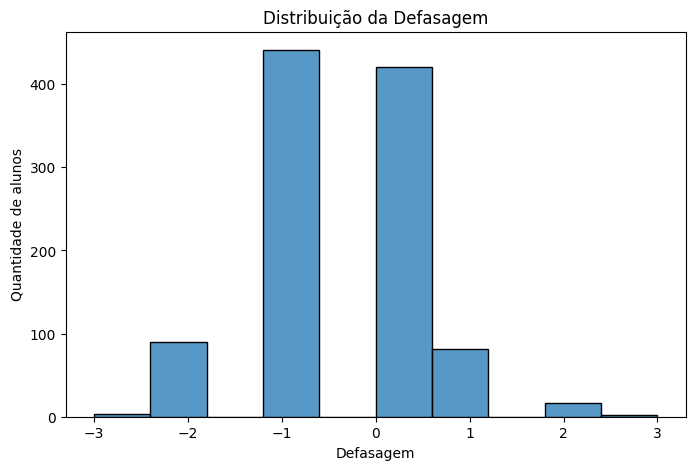

In [17]:
# ==============================
# 11. PERFIL GERAL DA DEFASAGEM
# ==============================

plt.figure(figsize=(8,5))

sns.histplot(
    pede_2024['Defasagem'],
    bins=10
)

plt.title(
    'Distribuição da Defasagem'
)

plt.xlabel(
    'Defasagem'
)

plt.ylabel(
    'Quantidade de alunos'
)

plt.show()

In [18]:
# ==============================
# 12. MÉDIA DOS INDICADORES
# ==============================

pede_2024[
    [
        'IDA',
        'IEG',
        'IAA',
        'IPS',
        'IPP',
        'IPV',
        'IAN'
    ]
].mean().sort_values()

IDA    6.349858
IPS    6.829670
IPV    7.354268
IAN    7.459677
IPP    7.548303
IEG    8.088696
IAA    8.543563
dtype: float64

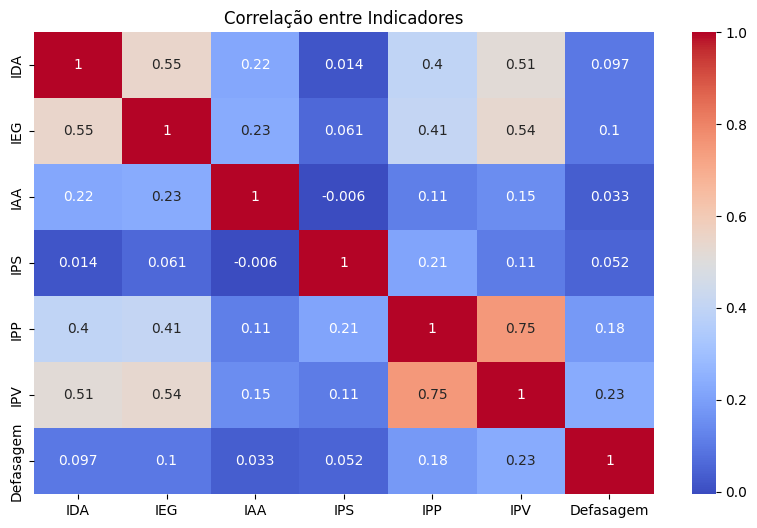

In [20]:
# ==============================
# 13. CORRELAÇÃO ENTRE INDICADORES
# ==============================

plt.figure(figsize=(10,6))

sns.heatmap(
    
    pede_2024[
        [
            'IDA',
            'IEG',
            'IAA',
            'IPS',
            'IPP',
            'IPV',
            'Defasagem'
        ]
    ].corr(),
    
    annot=True,
    
    cmap='coolwarm'
)

plt.title(
    'Correlação entre Indicadores'
)

plt.show()

In [21]:
# ==============================
# 14. CRIAÇÃO DA VARIÁVEL ALVO
# ==============================

pede_2024[
    'risco_defasagem'
] = np.where(
    
    pede_2024['Defasagem'] < 0,
    
    1,
    
    0
)

In [22]:
# ==============================
# 15. DISTRIBUIÇÃO DO RISCO
# ==============================

pede_2024[
    'risco_defasagem'
].value_counts()

risco_defasagem
1    534
0    520
Name: count, dtype: int64

In [23]:
# ==============================
# 16. SELEÇÃO DAS FEATURES
# ==============================

features = [
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV'
]

X = pede_2024[
    features
]

y = pede_2024[
    'risco_defasagem'
]

In [24]:
# ==============================
# 17. SEPARAÇÃO TREINO E TESTE
# ==============================

X_train, X_test, y_train, y_test = (
    
    train_test_split(
        
        X,
        y,
        
        test_size=0.2,
        
        random_state=42,
        
        stratify=y
    )
)

In [25]:
# ==============================
# 18. TREINAMENTO DO MODELO
# ==============================

modelo = (
    
    GradientBoostingClassifier(
        random_state=42
    )
)

modelo.fit(
    X_train,
    y_train
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [26]:
# ==============================
# 19. PREVISÕES
# ==============================

pred = modelo.predict(
    X_test
)

In [27]:
# ==============================
# 20. AVALIAÇÃO DO MODELO
# ==============================

print(
    "Acurácia:",
    
    accuracy_score(
        y_test,
        pred
    )
)

Acurácia: 0.6398104265402843


In [28]:
# ==============================
# 21. RELATÓRIO DE CLASSIFICAÇÃO
# ==============================

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.65      0.59      0.62       104
           1       0.63      0.69      0.66       107

    accuracy                           0.64       211
   macro avg       0.64      0.64      0.64       211
weighted avg       0.64      0.64      0.64       211



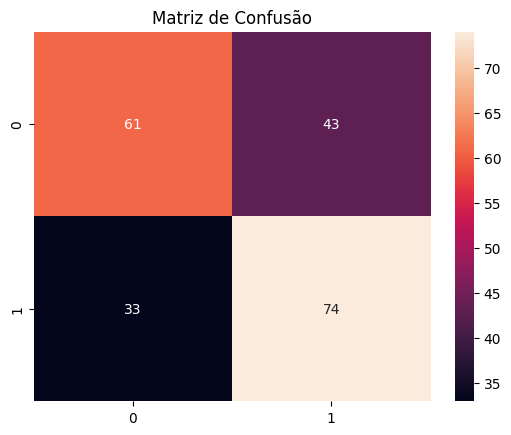

In [29]:
# ==============================
# 22. MATRIZ DE CONFUSÃO
# ==============================

cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d'
)

plt.title(
    'Matriz de Confusão'
)

plt.show()

In [30]:
# ==============================
# 23. IMPORTÂNCIA DAS FEATURES
# ==============================

importancias = pd.DataFrame({
    
    'Variavel': features,
    
    'Importancia':
    modelo.feature_importances_
})

importancias = (
    
    importancias.sort_values(
        
        by='Importancia',
        
        ascending=False
    )
)

importancias

,Variavel,Importancia
5,IPV,0.250782
1,IEG,0.233728
3,IPS,0.155547
0,IDA,0.137233
4,IPP,0.112409
2,IAA,0.110301


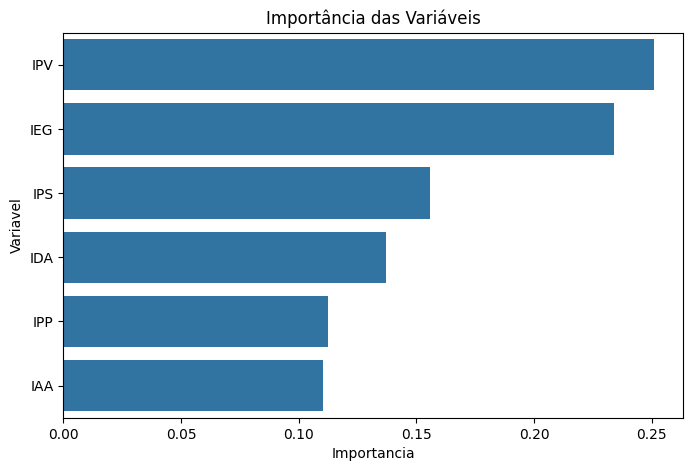

In [31]:
# ==============================
# 24. GRÁFICO DAS IMPORTÂNCIAS
# ==============================

plt.figure(figsize=(8,5))

sns.barplot(
    
    data=importancias,
    
    x='Importancia',
    
    y='Variavel'
)

plt.title(
    'Importância das Variáveis'
)

plt.show()

In [32]:
# ==============================
# 25. SALVAR MODELO
# ==============================

joblib.dump(
    modelo,
    'modelo_defasagem.pkl'
)

['modelo_defasagem.pkl']

# 26. CONCLUSÃO

O modelo apresentou desempenho moderado na identificação de alunos em risco de defasagem.

Os resultados indicam que fatores relacionados ao ponto de virada (IPV), engajamento (IEG) e aspectos psicossociais (IPS) possuem influência significativa no risco educacional dos alunos.

A solução desenvolvida permite identificar possíveis situações de risco de forma antecipada, contribuindo para intervenções mais rápidas e direcionadas pela ONG Passos Mágicos.